Jason Stys

In [ ]:
# Cell 1 — Load dependencies

import random
import numpy as np
import tensorflow as tf
import keras

from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout  # new!
from tensorflow.keras.layers import BatchNormalization  # new!

from keras.optimizers import Adam
from matplotlib import pyplot as plt
import pandas as pd

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
# Cell 2 — Load data

(x_train, y_train), (x_valid, y_valid) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Cell 3 — Preprocess data

x_train = x_train.reshape(60000, 784).astype('float32')
x_valid = x_valid.reshape(10000, 784).astype('float32')

x_train /= 255
x_valid /= 255

n_classes = 10
y_train = keras.utils.to_categorical(y_train, n_classes)
y_valid = keras.utils.to_categorical(y_valid, n_classes)

In [ ]:
# Cell 4 — CA hyperparameters (use the "best" combo here)

N_HIDDEN_LAYERS = 3
HIDDEN_UNITS = 64
ACTIVATION = 'relu'
LEARNING_RATE = 0.001

EPOCHS = 20
BATCH_SIZE = 128

def build_model(dropout_rate):
    model = Sequential()

    model.add(Dense(HIDDEN_UNITS, activation=ACTIVATION, input_shape=(784,)))
    model.add(BatchNormalization())

    for _ in range(N_HIDDEN_LAYERS - 1):
        model.add(Dense(HIDDEN_UNITS, activation=ACTIVATION))
        model.add(BatchNormalization())

    model.add(Dropout(dropout_rate))
    model.add(Dense(n_classes, activation='softmax'))

    return model

In [ ]:
# Cell 5 — Run experiments for dropout (.1, .2, .3, .4, .5) and collect accuracy

dropout_rates = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []
histories = {}

for dr in dropout_rates:
    print("\n" + "=" * 60)
    print(f"Training with dropout = {dr:.1f}")
    print("=" * 60)

    model = build_model(dr)

    optimizer = Adam(learning_rate=LEARNING_RATE)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    history = model.fit(
        x_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1,
        validation_data=(x_valid, y_valid)
    )

    val_loss, val_acc = model.evaluate(x_valid, y_valid, verbose=0)

    results.append({
        "#Hidden layer": N_HIDDEN_LAYERS,
        "Activation Function": ACTIVATION,
        "Learning Rate": LEARNING_RATE,
        "Dropout": dr,
        "Accuracy": val_acc
    })

    histories[dr] = history

df_results = pd.DataFrame(results)
df_results["Accuracy"] = (df_results["Accuracy"] * 100).round(2)
df_results


Training with dropout = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.7964 - loss: 0.6672 - val_accuracy: 0.9543 - val_loss: 0.1478
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9556 - loss: 0.1508 - val_accuracy: 0.9614 - val_loss: 0.1249
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9677 - loss: 0.1044 - val_accuracy: 0.9651 - val_loss: 0.1135
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9758 - loss: 0.0769 - val_accuracy: 0.9655 - val_loss: 0.1077
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9818 - loss: 0.0591 - val_accuracy: 0.9707 - val_loss: 0.0990
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9856 - loss: 0.0467 - val_accuracy: 0.9697 - val_loss: 0.1006
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9871 - loss: 0.0399 - val_accuracy: 0.9690 - val_loss: 0.1092
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9897 - loss: 0.0343 - val_accuracy: 

,#Hidden layer,Activation Function,Learning Rate,Dropout,Accuracy
0,3,relu,0.001,0.1,97.43
1,3,relu,0.001,0.2,97.41
2,3,relu,0.001,0.3,97.33
3,3,relu,0.001,0.4,97.19
4,3,relu,0.001,0.5,97.03


Best dropout: 0.1 | Accuracy: 97.43


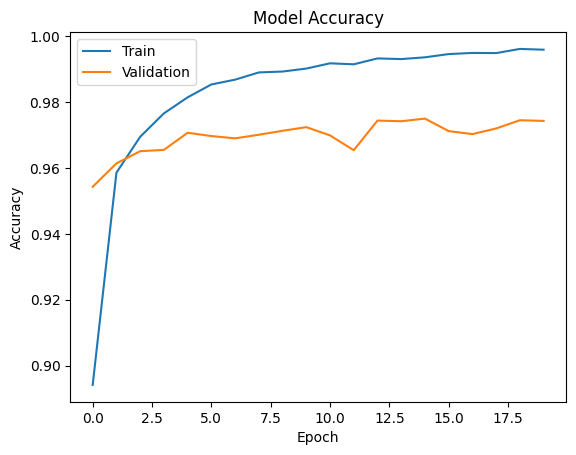

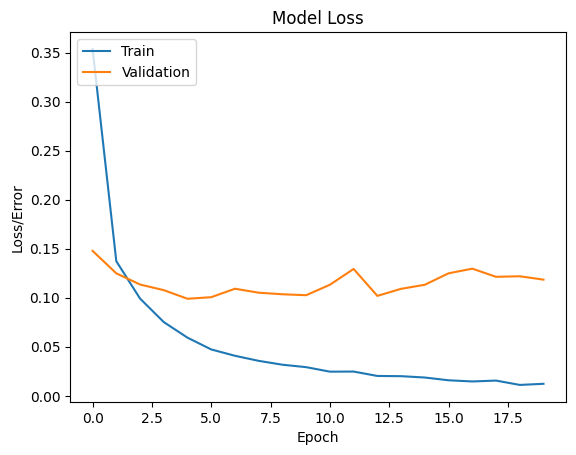

In [ ]:
# Cell 6 — Pick best dropout + draw the model history (same plotting style as slides)

best_row = df_results.sort_values("Accuracy", ascending=False).iloc[0]
best_dropout = float(best_row["Dropout"])
print("Best dropout:", best_dropout, "| Accuracy:", best_row["Accuracy"])

history = histories[best_dropout]

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss/Error')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# print(history.history.keys())
# pd.DataFrame(history.history).plot(figsize=(8,5))
# plt.show()